In [161]:
import os
import json
import csv

import matplotlib.pyplot as plt
from sankeyflow import Sankey

In [106]:
from cmat.clinvar_xml_io import ClinVarDataset
from cmat.clinvar_xml_io.filtering import filter_by_submission
from cmat.output_generation.clinvar_to_evidence_strings import load_ontology_mapping
from cmat.trait_mapping.ols import is_current_and_in_ontology

### Investigations for cleaning up trait mappings

In [87]:
def print_set(s, n=10):
    # Helper function to peek at large sets
    i = 0
    for x in s:
        print(x)
        i += 1
        if i > n:
            break

* How many mappings in the latest_mappings file are used in latest evidence strings / latest ClinVar?

In [22]:
# Get all trait names with EFO mappings from 2025.12 evidence
# To easily handle multiples we define a "mapping" as a pair: (trait_name, ontology_id)
# This mirrors how they're counted in the tsv files where each row is a mapping.

mappings_in_evidence = set()
with open(os.path.join(os.getenv('BATCH_ROOT'), 'batch-2025-12/evidence_strings/evidence_strings.json')) as f:
    for line in f:
        evidence = json.loads(line.strip())
        if evidence.get('diseaseFromSourceMappedId') and evidence.get('diseaseFromSource'):
            mappings_in_evidence.add((evidence.get('diseaseFromSource').lower(), evidence.get('diseaseFromSourceMappedId')))

The above method of getting used mappings does NOT work, due to [this quirk](https://github.com/EBIvariation/CMAT/issues/384) about how we annotate traits in ClinVar. For example:

```
$ grep -i 'focal facial dermal dysplasia type iii' trait_names_to_ontology_mappings.tsv
focal facial dermal dysplasia type iii  http://purl.obolibrary.org/obo/MONDO_0009203    focal facial dermal dysplasia type III
congenital ectodermal dysplasia of face http://www.orpha.net/ORDO/Orphanet_1807 Focal facial dermal dysplasia type III
focal facial dermal dysplasia 3, setleis type   http://www.orpha.net/ORDO/Orphanet_1807 Focal facial dermal dysplasia type III

$ grep -i 'focal facial dermal dysplasia type iii' batch-2025-12/evidence_strings/evidence_strings.json
<json abbreviated>
{..."cohortPhenotypes": ["BITEMPORAL FORCEPS MARKS SYNDROME", "FFDD type 2", "FOCAL FACIAL DERMAL DYSPLASIA, TYPE II", "Focal facial dermal dysplasia 3", "Focal facial dermal dysplasia 3, Setleis type", "Focal facial dermal dysplasia type III", "SETLEIS SYNDROME"],
    "diseaseFromSource": "Focal facial dermal dysplasia type III",
    "diseaseFromSourceId": "C1744559", 
    "diseaseFromSourceMappedId": "Orphanet_1807", ...}
{..."cohortPhenotypes": ["BITEMPORAL FORCEPS MARKS SYNDROME", "FFDD type 2", "FOCAL FACIAL DERMAL DYSPLASIA, TYPE II", "Focal facial dermal dysplasia 3", "Focal facial dermal dysplasia 3, Setleis type", "Focal facial dermal dysplasia type III", "SETLEIS SYNDROME"],
    "diseaseFromSource": "Focal facial dermal dysplasia type III", 
    "diseaseFromSourceId": "C1744559",
    "diseaseFromSourceMappedId": "Orphanet_398166", ...}
{..."cohortPhenotypes": ["BITEMPORAL FORCEPS MARKS SYNDROME", "FFDD type 2", "FOCAL FACIAL DERMAL DYSPLASIA, TYPE II", "Focal facial dermal dysplasia 3", "Focal facial dermal dysplasia 3, Setleis type", "Focal facial dermal dysplasia type III", "SETLEIS SYNDROME"],
    "diseaseFromSource": "Focal facial dermal dysplasia type III",
    "diseaseFromSourceId": "C1744559",
    "diseaseFromSourceMappedId": "MONDO_0009203", ...}
<more results>

# The other two mappings appear above, check the third
$ grep -i 'Orphanet_398166' trait_names_to_ontology_mappings.tsv
congenital ectodermal dysplasia of face http://www.orpha.net/ORDO/Orphanet_398166       Focal facial dermal dysplasia
focal facial dermal dysplasia 3, setleis type   http://www.orpha.net/ORDO/Orphanet_398166       Focal facial dermal dysplasia
```
Note that both [Orphanet_1807](https://www.ebi.ac.uk/ols4/ontologies/efo/classes/http%253A%252F%252Fwww.orpha.net%252FORDO%252FOrphanet_1807) and [Orphanet_398166](https://www.ebi.ac.uk/ols4/ontologies/efo/classes/http%253A%252F%252Fwww.orpha.net%252FORDO%252FOrphanet_398166) are deprecated in EFO, which is what Issue 384 is about.

This issue is a separate one from what we're investigating (though not using previous mappings would mitigate this as well). For the purposes of this investigation, the point is that these `(diseaseFromSource, diseaseFromSourceMappedId)` tuples are not actually the mappings we should be using for counts!

In [101]:
# Instead run an abridged version of the evidence string pipeline with only trait mappings
clinvar_xml = os.path.join(os.getenv('BATCH_ROOT'), 'batch-2025-12/clinvar/clinvar.xml.gz')
latest_mappings_file = os.path.join(os.getenv('BATCH_ROOT'), 'manual_curation/2025-10-02/trait_names_to_ontology_mappings.tsv')

In [109]:
latest_mappings, _ = load_ontology_mapping(latest_mappings_file)

INFO:cmat.output_generation:15972 ontology mappings loaded for ontology EFO


In [116]:
mappings_in_evidence = {}

dataset = ClinVarDataset(clinvar_xml)
clinvar_total = 0
for clinvar_set in dataset.iter_cvs():
    clinvar_total += 1
    if clinvar_total % 100000 == 0:
        print(f'{clinvar_total} records processed')

    try:
        # Records skipped by evidence string pipeline
        if not filter_by_submission(clinvar_set):
            continue
        clinvar_record = clinvar_set.rcv
        
        if len(clinvar_record.clinical_classifications) > 1:
            continue
        if not clinvar_record.traits_with_valid_names:
            continue
        if not clinvar_record.valid_clinical_significances:
            continue
        if clinvar_record.measure is None:
            continue

        # Get EFO mappings
        for trait in clinvar_record.traits_with_valid_names:
            for trait_name in trait.all_names:
                for uri, label in latest_mappings.get(trait_name.lower(), []):
                    mappings_in_evidence[(trait_name.lower(), uri.split('/')[-1])] = uri

    except Exception as e:
        print(f'Problem getting mappings for {clinvar_set.rcv.accession}: {repr(e)}')
        continue
        
print(f'{clinvar_total} records processed')

100000 records processed
200000 records processed
300000 records processed
400000 records processed
500000 records processed
600000 records processed
700000 records processed
800000 records processed
900000 records processed
1000000 records processed
1100000 records processed
1200000 records processed
1300000 records processed
1400000 records processed
1500000 records processed
1600000 records processed
1700000 records processed
1800000 records processed
1900000 records processed
2000000 records processed
2100000 records processed
2200000 records processed
2300000 records processed
2400000 records processed
2500000 records processed
2600000 records processed
2700000 records processed
2800000 records processed
2900000 records processed
3000000 records processed
3100000 records processed
3200000 records processed
3300000 records processed
3400000 records processed
3500000 records processed
3600000 records processed
3700000 records processed
3800000 records processed
3900000 records proce

In [118]:
# Dump mappings_in_evidence so we don't need to rerun
with open('mappings_in_evidence.csv', 'w') as f:
    writer = csv.writer(f, delimiter=',')
    for row in mappings_in_evidence:
        writer.writerow(row)

In [119]:
len(mappings_in_evidence)

13689

In [120]:
!wc ${BATCH_ROOT}/manual_curation/latest_mappings.tsv

  15975  142159 1860681 /nfs/production/keane/eva/opentargets/manual_curation/latest_mappings.tsv


In [121]:
# Percentage of mappings being used in latest evidence
13689/15975

0.8569014084507042

* How many mappings are being used but are bypassing curation completely (high confidence from Zooma or exact match from OLS)?
* Are there any mappings that are used in evidence strings but aren’t in the most recent curated and automated mappings?

In [128]:
# Check where these mappings come from: most recent automated mappings, most recent manual curation, or neither

# Use a dict so we can hash on (trait_name, ontology_id), but keep the URI to check obsoleteness
automated_mappings = {}
with open(os.path.join(os.getenv('BATCH_ROOT'), 'manual_curation/2025-10-02/automated_trait_mappings.tsv')) as f:
    for line in f:
        trait_name, ontology_uri, ontology_label = line.strip().split('\t')
        automated_mappings[(trait_name.lower(), ontology_uri.split('/')[-1])] = ontology_uri

In [129]:
len(automated_mappings)

11075

In [130]:
curated_mappings = {}
with open(os.path.join(os.getenv('BATCH_ROOT'), 'manual_curation/2025-10-02/finished_curation_spreadsheet.csv')) as f:
    reader = csv.reader(f, dialect='excel')
    # skip header
    next(reader)
    next(reader)
    for row in reader:
        if row[5] == 'DONE' and row[0] and row[7]:
            curated_mappings[(row[7].lower(), row[0].split('/')[-1])] = row[0]

In [131]:
len(curated_mappings)

371

In [133]:
# Mappings in latest carried over from previous (not from automated or curated)
15975 - (11075 + 371)

4529

In [134]:
mappings_used_in_automated = set()
mappings_used_in_curated = set()
mappings_used_in_neither = set()  # these are "previous mappings" only
mappings_used_in_both = set()  # sanity check - this should never happen!

for mapping in mappings_in_evidence:
    if mapping in automated_mappings and mapping not in curated_mappings:
        mappings_used_in_automated.add(mapping)
    if mapping not in automated_mappings and mapping in curated_mappings:
        mappings_used_in_curated.add(mapping)
    if mapping in automated_mappings and mapping in curated_mappings:
        mappings_used_in_both.add(mapping)
    if mapping not in automated_mappings and mapping not in curated_mappings:
        mappings_used_in_neither.add(mapping)

In [135]:
len(mappings_used_in_automated)

11059

In [136]:
len(mappings_used_in_curated)

366

In [140]:
len(mappings_used_in_neither)

2264

In [141]:
len(mappings_used_in_both)

0

In [142]:
# Confirm these add up to the number of mappings used in the evidence
11059 + 366 + 2264

13689

In [151]:
# How many in each of these categories are obsolete?

def get_num_obsolete(mapping_set):
    num_obsolete = 0
    for mapping in mapping_set:
        if not is_current_and_in_ontology(mappings_in_evidence[mapping]):
            num_obsolete += 1
    return num_obsolete       

In [152]:
get_num_obsolete(mappings_used_in_automated)

13

In [153]:
get_num_obsolete(mappings_used_in_curated)

3

In [154]:
get_num_obsolete(mappings_used_in_neither)

717

In [157]:
# Number of current EFO mappings used in the current evidence that are only present in previous mappings,
# i.e. not in the latest automated or curated mappings.
2264-717

1547

This exceeds the 716 multiple mappings found previously, so these can't all be duplicate terms. The question is, where are these coming from and why are they not present in Zooma or automated mappings more generally?

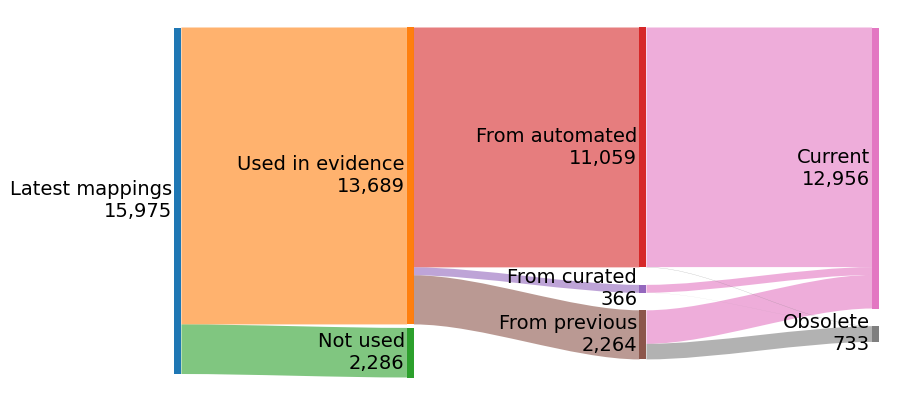

In [173]:
# Visualise what we have so far
plt.figure(figsize=(10, 5))
flows = [
    ('Latest mappings', 'Used in evidence', 13689),
    ('Latest mappings', 'Not used', 15975-13689),
    ('Used in evidence', 'From automated', 11059),
    ('Used in evidence', 'From curated', 366),
    ('Used in evidence', 'From previous', 2264),
    ('From automated', 'Current', 11059-13),
    ('From curated', 'Current', 366-3),
    ('From previous', 'Current', 2264-717),
    ('From automated', 'Obsolete', 13),
    ('From curated', 'Obsolete', 3),
    ('From previous', 'Obsolete', 717),
]
s = Sankey(flows=flows)
s.draw()
plt.show()

* Are there mapping that used to be high confidence in automated mapping and subsequently was mapped with low confidence